<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke07-velferdsteknologi/04_sikkerhet_etikk_og_menneske_maskin_samspill.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 10-25 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig
- Data: syntetisk/simulert data
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [1]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = []
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


Miljø: lokalt
Datamønster: synthetic-or-inline


# ⚠️ Sikkerhet, etikk og menneske-maskin-samspill

I de tre foregående notebookene har vi gått fra robotnavigasjon til sensortolkning og videre til beslutningsstøtte. Denne siste notebooken samler trådene ved å stille et overordnet spørsmål: Når er velferdsteknologi faktisk trygg, forsvarlig og god å bruke i praksis?

Poenget er at selv teknologier som fungerer teknisk, kan skape problemer dersom de oppleves som uforståelige, invaderende eller vanskelige å følge opp. Derfor avslutter vi uken med å løfte blikket fra enkeltalgoritmer og se på sikkerhet, etikk, ansvar og menneske-maskin-samspill som en samlet del av implementeringen.

## Læringsmål
- identifisere sikkerhetsutfordringer i velferdsteknologiske systemer
- forstå hvorfor menneske-maskin-samspill påvirker trygg bruk
- reflektere over personvern, autonomi og verdighet i overvåkingsnære teknologier
- diskutere hvordan teknologi kan støtte uten å overstyre brukeren

### 🔧 Miljøoppsett – fungerer både lokalt og i Google Colab

In [2]:
import sys, os, subprocess
import matplotlib.pyplot as plt

# Vi sjekker om notebooken kjøres i Google Colab eller lokalt.
# Det er nyttig fordi arbeidsmappe og tilgang til repoet kan være forskjellig i de to miljøene.
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Kjører i Google Colab")

    # Hvis kursrepoet ikke allerede finnes i Colab-økten, laster vi det ned fra GitHub.
    if not os.path.exists('AI-og-helse'):
        print("📥 Laster ned kursmateriell...")
        subprocess.check_call(["git", "clone", "https://github.com/arvidl/AI-og-helse.git"])

    # Når repoet er tilgjengelig, bytter vi til riktig arbeidsmappe.
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Byttet til mappe: {os.getcwd()}")
else:
    # Ved lokal kjøring antar vi at brukeren allerede står i riktig mappe.
    print("💻 Kjører i lokalt miljø")

# Standard figurstørrelse gjør figuren lettere å lese.
plt.rcParams['figure.figsize'] = (10, 4)

print("✅ Miljø klart")

💻 Kjører i lokalt miljø
✅ Miljø klart


## Trygg teknologi handler også om samspill

Et teknisk system kan være korrekt i snever forstand, men likevel fungere dårlig i praksis hvis:

- brukeren ikke forstår hva systemet gjør
- systemet varsler for ofte eller på feil tidspunkt
- teknologien oppleves som invaderende
- brukeren mister kontroll eller autonomi

I velferdsteknologi må vi derfor vurdere både **teknisk sikkerhet** og **opplevd trygghet**.

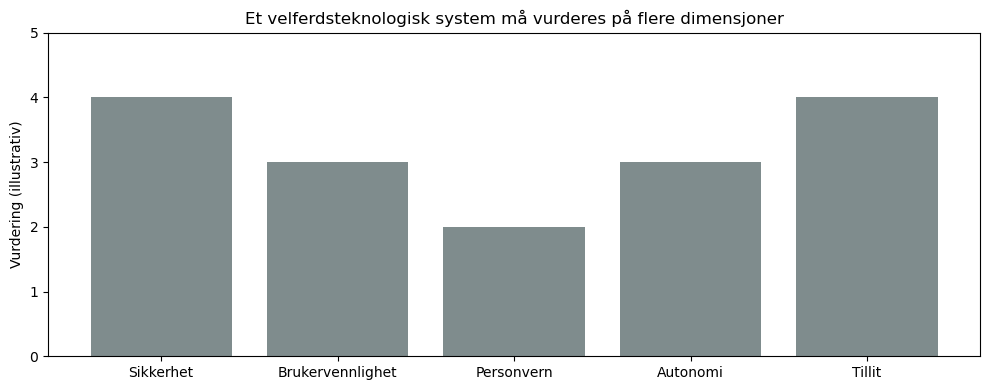

In [3]:
# Vi lager en enkel, illustrativ oversikt over noen sentrale vurderingsdimensjoner.
# Poenget er å vise at et velferdsteknologisk system ikke bare må vurderes teknisk,
# men også ut fra hvordan det fungerer for brukere, ansatte og tjenesten som helhet.

kategorier = ['Sikkerhet', 'Brukervennlighet', 'Personvern', 'Autonomi', 'Tillit']
verdier = [4, 3, 2, 3, 4]

# Stolpediagrammet gir en enkel visuell påminnelse om at flere hensyn må balanseres samtidig.
# Verdiene er bare illustrative og representerer ikke en virkelig måling.
plt.bar(kategorier, verdier, color='#7f8c8d')
plt.ylim(0, 5)
plt.ylabel('Vurdering (illustrativ)')
plt.title('Et velferdsteknologisk system må vurderes på flere dimensjoner')
plt.tight_layout()
plt.show()

## Etiske spørsmål i praksis

Når teknologi brukes i hjemmet eller tett på sårbare brukere, oppstår flere spørsmål:

- Hvor mye overvåking er akseptabelt?
- Hvem bestemmer hva som er «normal aktivitet»?
- Hvordan bevarer vi verdighet og autonomi?
- Hva skjer hvis systemet gjør feil eller misforstår situasjonen?

Disse spørsmålene peker fram mot uke 08, der ansvarlig implementering, etikk og trustworthy AI blir hovedtema.

In [4]:
# Denne funksjonen skriver ut en enkel sjekkliste for trygg bruk av teknologi.
# Hensikten er å vise at sikkerhet og etikk ofte må konkretiseres i praktiske spørsmål,
# ikke bare i overordnede prinsipper.
def enkel_sjekkliste():
    punkter = [
        'Kan brukeren forstå hva systemet gjør?',
        'Finnes det trygg fallback hvis teknologien svikter?',
        'Er varsler og anbefalinger tilpasset brukssituasjonen?',
        'Er personvern og verdighet vurdert?',
        'Er det tydelig hvem som følger opp feil eller alarmer?'
    ]

    # Vi skriver ut en enkel tekstbasert sjekkliste som kan brukes som utgangspunkt for refleksjon.
    print('SJEKKLISTE FOR TRYGG BRUK')
    print('=' * 30)
    for punkt in punkter:
        print(f'☐ {punkt}')

# Vi kaller funksjonen for å vise hvordan sjekklisten ser ut i praksis.
enkel_sjekkliste()

SJEKKLISTE FOR TRYGG BRUK
☐ Kan brukeren forstå hva systemet gjør?
☐ Finnes det trygg fallback hvis teknologien svikter?
☐ Er varsler og anbefalinger tilpasset brukssituasjonen?
☐ Er personvern og verdighet vurdert?
☐ Er det tydelig hvem som følger opp feil eller alarmer?


### Refleksjon
- Når blir overvåking i hjemmet en støtte, og når blir den en belastning?
- Hva betyr menneskelig kontroll i et velferdsteknologisk system?
- Hvordan kan teknologi støtte brukeren uten å redusere autonomi og verdighet?

## Oppsummering

Denne notebooken avslutter uke 07 ved å samle de tekniske eksemplene fra robotnavigasjon, sensortolkning og beslutningsstøtte i en bredere vurdering av sikkerhet, etikk og menneske-maskin-samspill.

Videre i uke 08 går vi dypere inn i ansvarlig implementering, personvern, regulering og tillit til AI-systemer i helse og omsorg.